# 🎯 Simulación de Eventos Discretos
## De Cero a Experto: Una Guía Práctica y Didáctica

**Autor:** Curso de Modelado bajo Incertidumbre  
**Objetivo:** Aprender a modelar y simular sistemas complejos paso a paso

---

## 📋 Índice del Notebook

1. **Motivación**¿Por qué necesitamos simulación?
2. **Conceptos Fundamentales** - Desde cero
3. **Ejemplo Manual** - Trabajando a mano
4. **Construyendo un Simulador** - Paso a paso
5. **Aplicaciones Prácticas** - Colas, Inventarios, Finanzas
6. **Análisis Avanzado** - Validación y optimización
7. **Ejercicios Guiados** - Para practicar

---

## 🚀 ¿Qué aprenderás?

✅ Qué es la simulación de eventos discretos y cuándo usarla  
✅ Construir un simulador desde cero  
✅ Modelar sistemas reales (bancos, almacenes, mercados)  
✅ Analizar resultados y tomar decisiones  
✅ Comparar con teoría de colas  
✅ Optimizar parámetros del sistema

## 1️⃣ MOTIVACIÓN: El Problema del Gerente

### 🏦 Escenario Real

Imagina que eres gerente de un banco. Cada mañana enfrentas una decisión crítica:

**❓ ¿Cuántos cajeros debo tener abiertos?**

- **Muy pocos**: Los clientes esperan mucho y se van molestos 😠
- **Demasiados**: El costo de personal es muy alto 💰
- **¿Punto óptimo?**: ¿Existe? ¿Cómo encontrarlo?

### 🤔 Opciones para Resolver esto

| Opción | Descripción | Problema |
|--------|-------------|----------|
| **Prueba y error** | Ir cambiando cajeros y ver qué pasa | ❌ Clientes reales molestos |
| **Intuición** | "Creo que con 3 está bien" | ❌ Puede estar muy equivocado |
| **Fórmulas matemáticas** | Teoría de colas (M/M/c) | ⚠️ Requiere supuestos fuertes |
| **✅ SIMULACIÓN** | Imitar el sistema en computadora | ✅ Sin riesgo, flexible, realista |

### 💡 La Solución: Simulación

**Simular = Crear una "copia virtual" del sistema en la computadora**

- Generamos clientes artificiales que llegan aleatoriamente
- Los hacemos pasar por cajeros virtuales  
- Medimos tiempos de espera, colas, etc.
- Probamos diferentes configuraciones
- **¡Encontramos la mejor sin afectar el banco real!**

---

### 📊 Tipos de Simulación

| Tipo | ¿Cómo avanza el tiempo? | Ejemplo |
|------|------------------------|---------|
| **Eventos Discretos** (DES) | Salta de evento en evento | Bancos, inventarios, hospitales |
| **Continua** | Avanza continuamente | Flujos de agua, temperaturas |
| **Monte Carlo** | No hay tiempo | Valuación de opciones, riesgo |

**En este notebook nos enfocamos en: SIMULACIÓN DE EVENTOS DISCRETOS** 🎯

## 2️⃣ CONCEPTOS FUNDAMENTALES (Desde Cero)

### 🎪 Analogía: La Función de Teatro

Imagina que estás organizando una función de teatro. Los eventos discretos son como los momentos clave:

```
t=0:     Teatro vacío
t=19:00: Abre la taquilla → EVENTO (personas entran)
t=19:15: Llega grupo de 10 → EVENTO (van a fila)
t=19:30: Cierra taquilla → EVENTO
t=19:45: Empieza obra → EVENTO
t=21:30: Termina obra → EVENTO (todos salen)
```

**Entre eventos, nada cambia**. No necesitas simular cada segundo.

---

### 🔑 Los 5 Conceptos Clave

#### 1. **EVENTO**
- **Definición**: Algo que sucede en un instante y cambia el sistema
- **Ejemplos**: 
  - ✅ Cliente llega (t=2.5 min)
  - ✅ Cajero termina de atender (t=5.3 min)
  - ❌ "El cliente está esperando" (NO es evento, es estado)

#### 2. **RELOJ DE SIMULACIÓN**  
- **Definición**: Variable que lleva el tiempo actual
- **Analogía**: Como el reloj de tu celular
- **Importante**: ¡Salta de evento en evento! (no avanza continuamente)

#### 3. **LISTA DE EVENTOS FUTUROS (FEL)**
- **Definición**: Agenda ordenada de eventos pendientes
- **Analogía**: Tu calendario con recordatorios
- **Estructura**: Heap (siempre sacamos el evento más cercano)

#### 4. **ESTADO DEL SISTEMA**
- **Definición**: Variables que describen el sistema ahora
- **Ejemplos**:
  - Número de clientes en cola: 3
  - Cajero ocupado: Sí/No
  - Tiempo actual: 15.7 min

#### 5. **ENTIDAD**
- **Definición**: Objetos que fluyen por el sistema
- **Ejemplos**: Clientes, productos, paquetes, órdenes de compra

### 🔄 El Algoritmo Básico

```python
# Pseudocódigo de cualquier simulación DES
tiempo_actual = 0
agenda = []  # Lista de eventos futuros

# Programar eventos iniciales
agenda.agregar(Evento(tipo="llegada", tiempo=2.0))

# Loop principal
while hay_eventos_pendientes and tiempo_actual < tiempo_max:
    evento = agenda.sacar_el_mas_cercano()
    tiempo_actual = evento.tiempo
    
    if evento.tipo == "llegada":
        manejar_llegada(evento)
    elif evento.tipo == "salida":
        manejar_salida(evento)
```

---

### 📈 Visualización del Proceso

Veamos cómo funciona con un diagrama:

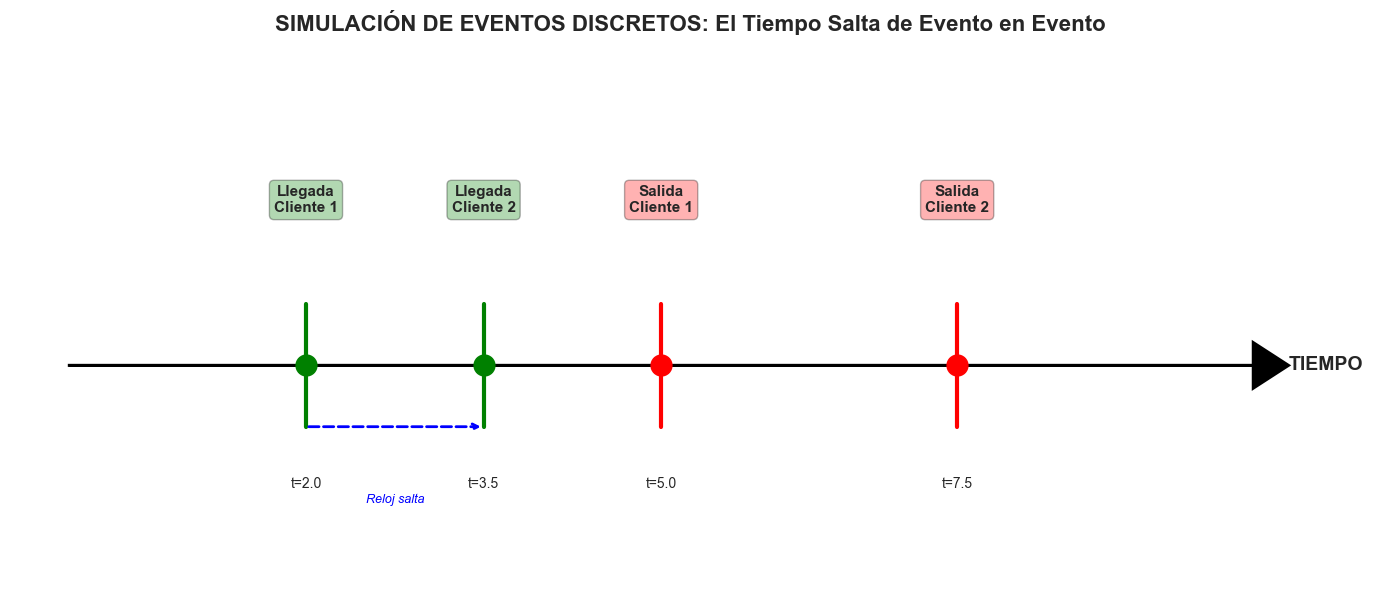

💡 OBSERVA:
   - El tiempo NO avanza continuamente
   - SALTA de un evento al siguiente
   - Entre eventos, nada cambia en el sistema


In [24]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

# Línea de tiempo
ax.arrow(0, 0.5, 10, 0, head_width=0.15, head_length=0.3, fc='black', ec='black', linewidth=2)
ax.text(10.3, 0.5, 'TIEMPO', fontsize=14, fontweight='bold', va='center')

# Eventos
eventos = [
    (2.0, "Llegada\nCliente 1", 'green'),
    (3.5, "Llegada\nCliente 2", 'green'),
    (5.0, "Salida\nCliente 1", 'red'),
    (7.5, "Salida\nCliente 2", 'red')
]

for t, label, color in eventos:
    # Marca en la línea
    ax.plot([t, t], [0.3, 0.7], color=color, linewidth=3)
    ax.plot(t, 0.5, 'o', color=color, markersize=15)
    
    # Etiqueta
    ax.text(t, 1.0, label, ha='center', fontsize=11, fontweight='bold', 
            bbox=dict(boxstyle='round', facecolor=color, alpha=0.3))
    
    # Tiempo
    ax.text(t, 0.1, f't={t}', ha='center', fontsize=10)

# Reloj salta
ax.annotate('', xy=(3.5, 0.3), xytext=(2.0, 0.3),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2, ls='--'))
ax.text(2.75, 0.05, 'Reloj salta', ha='center', fontsize=9, color='blue', style='italic')

ax.set_xlim(-0.5, 11)
ax.set_ylim(-0.2, 1.5)
ax.axis('off')
ax.set_title('SIMULACIÓN DE EVENTOS DISCRETOS: El Tiempo Salta de Evento en Evento', 
             fontsize=16, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("💡 OBSERVA:")
print("   - El tiempo NO avanza continuamente")
print("   - SALTA de un evento al siguiente")
print("   - Entre eventos, nada cambia en el sistema")